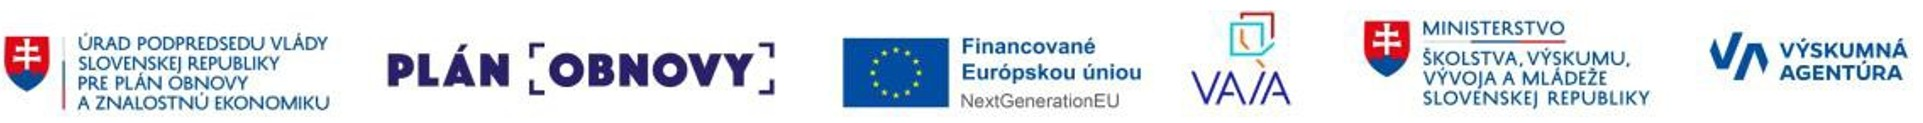

## Project identification

| | |
|---|---|
| **Project title** | A Statistical Approach to Monitor Quantisation in Neural Network Training |
| **Project acronym** | SAMQ-NN |
| **Project code** | 09I03-03-V04-00562 |
| **Programme** | Recovery and Resilience Plan of the Slovak Republic |
| **Component** | 9. More effective governance and strengthening of the funding of research, development and innovation under the Recovery and Resilience Plan of the Slovak Republic |
| **Investment** | 3. Excellent science |
| **Aid scheme** | State aid scheme to support research, development and innovation under Component 9 of the Recovery and Resilience Plan of the Slovak Republic, No. SA.106633 |
| **Project start** | 06/2024 |
| **End of implementation** | 05/2026 |
| **Principal investigator** | Ing. Roman Budjač, PhD. |

# D11 - Solution options: Report from from prenetation on seminar as a part of WP3

This notebook illustrates the **concepts from the D11 seminar** on small, self-contained examples (numpy + scipy, runs on CPU). It is not a full implementation — that is the subject of **D12**. The goal is to show *variants* of the solution:

- **Option A** : methods for comparing weight distributions (KL, JS, cosine, Wasserstein),
- behaviour of the metrics across bit-widths,
- **Option B** : per-tensor vs per-channel quantisation,
- **Option C** : using the index (global / per-layer, automatic bit-width selection).

## Preparation: quantisation and reference weights

Simple uniform quantisation: rounding the weights onto a grid of 2ᵇ levels (min–max, per-tensor). `w_ref` represents the full-precision (FP32) reference model.

In [ ]:
import numpy as np
rng = np.random.default_rng(0)

def quantize(w, bits):
    "Per-tensor uniform quantisation: snap values onto a 2^bits grid (min-max)."
    lo, hi = float(w.min()), float(w.max())
    if hi == lo:
        return w.copy()
    q = 2 ** bits - 1
    s = (hi - lo) / q
    return np.round((w - lo) / s) * s + lo

# reference (FP32) weights and an 8-bit quantised copy
w_ref = rng.normal(0.0, 0.10, size=5000)
w_q8  = quantize(w_ref, 8)

print(f"reference : range [{w_ref.min():.3f}, {w_ref.max():.3f}], "
      f"distinct values = {len(np.unique(w_ref))}")
print(f"8-bit     : distinct values = {len(np.unique(w_q8))}  (max 2^8 = 256)")

reference : range [-0.390, 0.326], distinct values = 5000
8-bit     : distinct values = 210  (max 2^8 = 256)


## Option A : methods for comparing distributions

Common procedure: from both weight sets, histograms are built on the **same bin grid**, normalised to probability distributions (with a small ε) and compared with the chosen measure. The Wasserstein distance is computed directly from the samples.

In [ ]:
from scipy.stats import wasserstein_distance

def to_hist(x, edges, eps=1e-10):
    "Normalised histogram on fixed bin edges (+ eps to avoid zeros)."
    h, _ = np.histogram(x, bins=edges)
    h = h.astype(float) + eps
    return h / h.sum()

def kl_div(p, q):                       # asymmetric, unbounded (bits)
    return float(np.sum(p * np.log2(p / q)))

def js_div(p, q):                       # symmetric, bounded [0,1] (bits)
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def cosine_sim(p, q):                   # orientation of the distributions
    return float(p @ q / (np.linalg.norm(p) * np.linalg.norm(q)))

def index(p_samples, q_samples, metric="js", n_bins=100):
    "Statistical similarity index between two weight sets."
    lo = min(p_samples.min(), q_samples.min())
    hi = max(p_samples.max(), q_samples.max())
    edges = np.linspace(lo, hi, n_bins + 1)
    P, Q = to_hist(p_samples, edges), to_hist(q_samples, edges)
    return {"kl": kl_div(P, Q), "js": js_div(P, Q),
            "cosine": cosine_sim(P, Q),
            "wasserstein": wasserstein_distance(p_samples, q_samples)}[metric]

# compare a 4-bit quantised copy against the reference with all four metrics
w_q4 = quantize(w_ref, 4)
for m in ("kl", "js", "cosine", "wasserstein"):
    print(f"  {m:12s}: {index(w_ref, w_q4, m):.5f}")

  kl          : 33.29830
  js          : 0.67912
  cosine      : 0.38679
  wasserstein : 0.01189


## How the metrics behave across bit-widths

The results indicate that coarser quantisation, represented by a lower number of bits, leads to a larger deviation of the quantised weight distribution from the original distribution. This effect is reflected in the growth of the proposed index. Since the analysed measures are strongly correlated with one another, the choice of a particular metric does not substantially affect the final conclusion. The Jensen–Shannon divergence, however, represents a convenient practical choice owing to its bounded range and easier interpretability.

 bits |       JS |       KL |   cosine
    8 |   0.0080 |   0.0386 |   0.9800
    6 |   0.2134 |  14.0563 |   0.8011
    4 |   0.6791 |  33.2983 |   0.3868
    3 |   0.8204 |  36.7823 |   0.2355
    2 |   0.9055 |  38.3955 |   0.1475


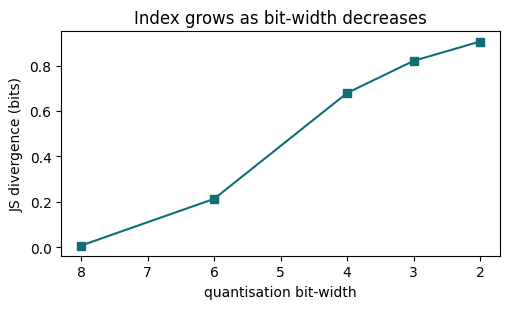

In [ ]:
bit_widths = [8, 6, 4, 3, 2]   # illustrative (incl. in-between values 6 and 3 to show the metric behaviour)
print(f"{'bits':>5} | {'JS':>8} | {'KL':>8} | {'cosine':>8}")
js_curve = []
for b in bit_widths:
    wq = quantize(w_ref, b)
    js, kl, cos = index(w_ref, wq, "js"), index(w_ref, wq, "kl"), index(w_ref, wq, "cosine")
    js_curve.append(js)
    print(f"{b:>5} | {js:>8.4f} | {kl:>8.4f} | {cos:>8.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(5.2, 3.2))
plt.plot(bit_widths, js_curve, "s-", color="#0F6E78")
plt.gca().invert_xaxis()
plt.xlabel("quantisation bit-width"); plt.ylabel("JS divergence (bits)")
plt.title("Index grows as bit-width decreases"); plt.tight_layout(); plt.show()

## Option B: per-tensor vs per-channel quantisation

Per-tensor quantisation uses a single shared scale for the entire weight tensor of a given layer, whereas per-channel quantisation assigns a separate scale to each output channel. For layers in which the value ranges differ markedly between channels, the per-channel approach provides a more accurate approximation of the original weights, which is reflected in a lower value of the proposed index.

In [ ]:
def quantize_per_channel(W, bits):
    "Quantise each output channel (last axis) with its own min-max scale."
    out = np.empty_like(W)
    for c in range(W.shape[-1]):
        out[..., c] = quantize(W[..., c], bits)
    return out

# weight matrix whose channels (columns) have very different scales
scales = np.logspace(-2, 0, 64)                 # 0.01 .. 1.0
W = rng.normal(0.0, 1.0, size=(256, 64)) * scales

W_pt = quantize(W.ravel(), 4).reshape(W.shape)  # per-tensor (one scale)
W_pc = quantize_per_channel(W, 4)               # per-channel

print(f"per-tensor : global index JS = {index(W.ravel(), W_pt.ravel(), 'js'):.4f}")
print(f"per-channel: global index JS = {index(W.ravel(), W_pc.ravel(), 'js'):.4f}")
print("per-channel is more accurate (lower index) -> robust even for deep networks")

per-tensor : global index JS = 0.7689
per-channel: global index JS = 0.0123
per-channel is more accurate (lower index) -> robust even for deep networks


## Option C: using the index

**Granularity:** global index (over all weights) vs per-layer (reveals the most sensitive layer).
**Role (predictor):** before training, select the lowest bit-width at which the index stays below the threshold.

In [ ]:
# a few "layers" with different weight tensors (demonstration)
layers = {
    "conv1": rng.normal(0, 0.10, (3, 3, 3, 16)),
    "conv2": rng.normal(0, 0.07, (3, 3, 16, 32)),
    "dense": rng.normal(0, 0.05, (128, 64)),
}

# global vs per-layer index - 4-bit
all_ref = np.concatenate([w.ravel() for w in layers.values()])
all_q   = np.concatenate([quantize(w, 4).ravel() for w in layers.values()])
print(f"global index (4-bit)   : JS = {index(all_ref, all_q, 'js'):.4f}\n")
print("per-layer index (4-bit):")
for name, w in layers.items():
    print(f"  {name:7s}: JS = {index(w.ravel(), quantize(w, 4).ravel(), 'js'):.4f}")

def auto_select_bitwidth(w, candidates=(4, 8, 16, 32), tau=0.01):
    "Predictor: lowest bit-width whose index stays under the threshold."
    for b in sorted(candidates):
        if index(w, quantize(w, b), "js") <= tau:
            return b
    return max(candidates)

print(f"\nauto_select_bitwidth(conv1, threshold=0.01) -> {auto_select_bitwidth(layers['conv1'].ravel())}-bit")

global index (4-bit)   : JS = 0.3270

per-layer index (4-bit):
  conv1  : JS = 0.7295
  conv2  : JS = 0.6795
  dense  : JS = 0.6795

auto_select_bitwidth(conv1, threshold=0.01) -> 16-bit


## Summary

- **Metric:** JS divergence as the primary one (bounded, thresholdable); KL and cosine as complementary.
- **Index granularity:** both global and per-layer.
- **Role:** both predictor (bit-width selection) and monitor (during training).
- **Quantisation:** per-channel for robustness with deep networks.

These building blocks form the basis of the **D12** implementation; the other options (Wasserstein, epoch-over-epoch reference, activation monitoring) remain as potential extensions.